In [1]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys
import os
from synphot import SpectralElement, Empirical1D, SourceSpectrum, Observation
from scipy.interpolate import RegularGridInterpolator

SPEC_PIPE_LOC = "{}/JPL/W12_Drops/spec_paper/Spec_pipeline".format(os.path.expanduser("~"))
sys.path.append(SPEC_PIPE_LOC)
os.environ['SPEC_PIPE_LOC'] = SPEC_PIPE_LOC
from Spec_pipeline import SDSS_Spec

sys.path.append("Gas_and_dust/")
from draine_dust import draine_dust

sys.path.append("Gas_and_dust/fullspec_dust_models/")
from polWaveDust import PolWaveDust

from polWave_gas import PolWave_gas

sys.path.append("../utility_functions/")
from objectProperties import ObjectProperties
from readExtrapolatedSpectra import ReadExtrapolatedSpectra

sys.path.append("../../Filter_Curves/")
from readBands import ReadBands

In [2]:
#Object ID
wid = "W0204-0506"

In [3]:
#Load the properties of the BHDs
op = ObjectProperties(wids=[wid])

In [4]:
#Load the bands.
bands = ReadBands()

In [5]:
#Load the spectra for each BHD, extended using the best-fit SED.
specs = ReadExtrapolatedSpectra()

#Put the W0204 spectrum in Synphot format. 
full_spec = SourceSpectrum(Empirical1D, points=specs.lam_obs[wid], lookup_table=specs.flam[wid], keep_neg=True)

Wavelength range for object W0019-1046 limited because of sky template
Spec-range: 3001.5 Angstrom - 5423.93 Angstrom
Sky-range: 3199.4 Angstrom - 6724.06 Angstrom
Wavelength range for object W0204-0506 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.70 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.
Wavelength range for object W0831+0140 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.45 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.


In [8]:
bnames = list(op.pfrac[wid].keys())

In [22]:
def get_p_bb(dust_type, theta_angles, psi_angles, specs, bnames, fw=True, bw=True):

    p_bb = dict()
    for bname in bnames:
        p_bb[bname] = np.zeros((len(theta_angles), len(psi_angles)))

    if dust_type=="gas":
        model = PolWave_gas(fw=fw,bw=bw)
        for bname in bnames:
            for jtheta, theta in enumerate(theta_angles):
                th_aux = theta*np.ones(len(psi_angles))
                p_bb[bname][jtheta] = model.p((th_aux, psi_angles))

    else:
        model = PolWaveDust(dust_type, folder="Gas_and_dust/fullspec_dust_models/", fw=fw, bw=bw)

        for bname in bnames:
            obs_I = Observation(full_spec, bands.bp[bname])
            Ibb = obs_I.effstim(flux_unit='flam').value
            for jtheta, theta in enumerate(theta_angles):
                for kpsi, psi in enumerate(psi_angles):
                    th_aux = theta*np.ones(len(specs.lam_obs[wid]))
                    psi_aux = psi*np.ones(len(specs.lam_obs[wid]))
                    p_lam = model.p((specs.lam_rest[wid].to(u.AA).value, th_aux, psi_aux))
                    
                    Q_spec = SourceSpectrum(Empirical1D, points=specs.lam_obs[wid], lookup_table=specs.flam[wid] * p_lam, keep_neg=True)

                    obs_Q = Observation(Q_spec, bands.bp[bname])
                    Qbb = obs_Q.effstim(flux_unit='flam').value
                    
                    p_bb[bname][jtheta, kpsi] = Qbb/Ibb
    return p_bb
    

In [25]:
def plot_pol(p_bb, theta_angles, psi_angles, ymax=1.02, plot_fname=None, plot_label=None, ax=None, fig=None):

    #Create the figure
    if fig is None and ax is None:
        fig, ax = plt.subplots(figsize=(12,9))

    #Set the normalization for the color map. 
    #Norm = mpl.colors.LogNorm(vmin=theta_s_angles[0], vmax=theta_s_angles[-1])
    Norm = mpl.colors.Normalize(vmin=theta_angles[0], vmax=theta_angles[-1])

    #Set the color map
    cmap = mpl.cm.jet

    #Run through every inclination angle plotting the curves.
    for jtheta, theta in enumerate(theta_angles):
        #Set the color
        c = cmap(Norm(theta))
        #Plot
        im = ax.plot(psi_angles, p_bb[jtheta], color=c, linestyle='solid')

    #Set the ticks to point inwards.
    ax.tick_params(axis='both', direction='in', labelsize=14, top=True, right=True)

    #Draw a colorbar. 
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=Norm, cmap=cmap), ax=ax, pad=0.01, aspect=30)
    #cb.set_label(label=r'Inclination Angle $\theta_S$ (deg)', fontsize=20)
    cb.set_label(label=r'Inclination Angle $\eta$ (deg)', fontsize=20)
    cb.ax.tick_params(labelsize=14) 

    #Set the axes limits.
    ax.set_xlim([0, np.max(psi_angles)])
    ax.set_ylim([0, ymax])

    #Set the axes labels.
    ax.set_ylabel('Polarization Fraction (\%)', fontsize=20)
    ax.set_xlabel(r'Opening Half-Angle $\psi$ (deg)', fontsize=20)

    #Set the main label in the top right corner. 
    if plot_label is not None:
        ax.text(0.98, 0.9, plot_label, va='center', ha='right', transform=ax.transAxes, fontsize=26)

    #Show the plot.
    if plot_fname is not None:
        plt.savefig(plot_fname, dpi=300, bbox_inches='tight')
    else:
        #plt.show()
        pass

In [10]:
theta_angles = np.arange(0., 90., 1.)
psi_angles = np.arange(0., 90., 1.)

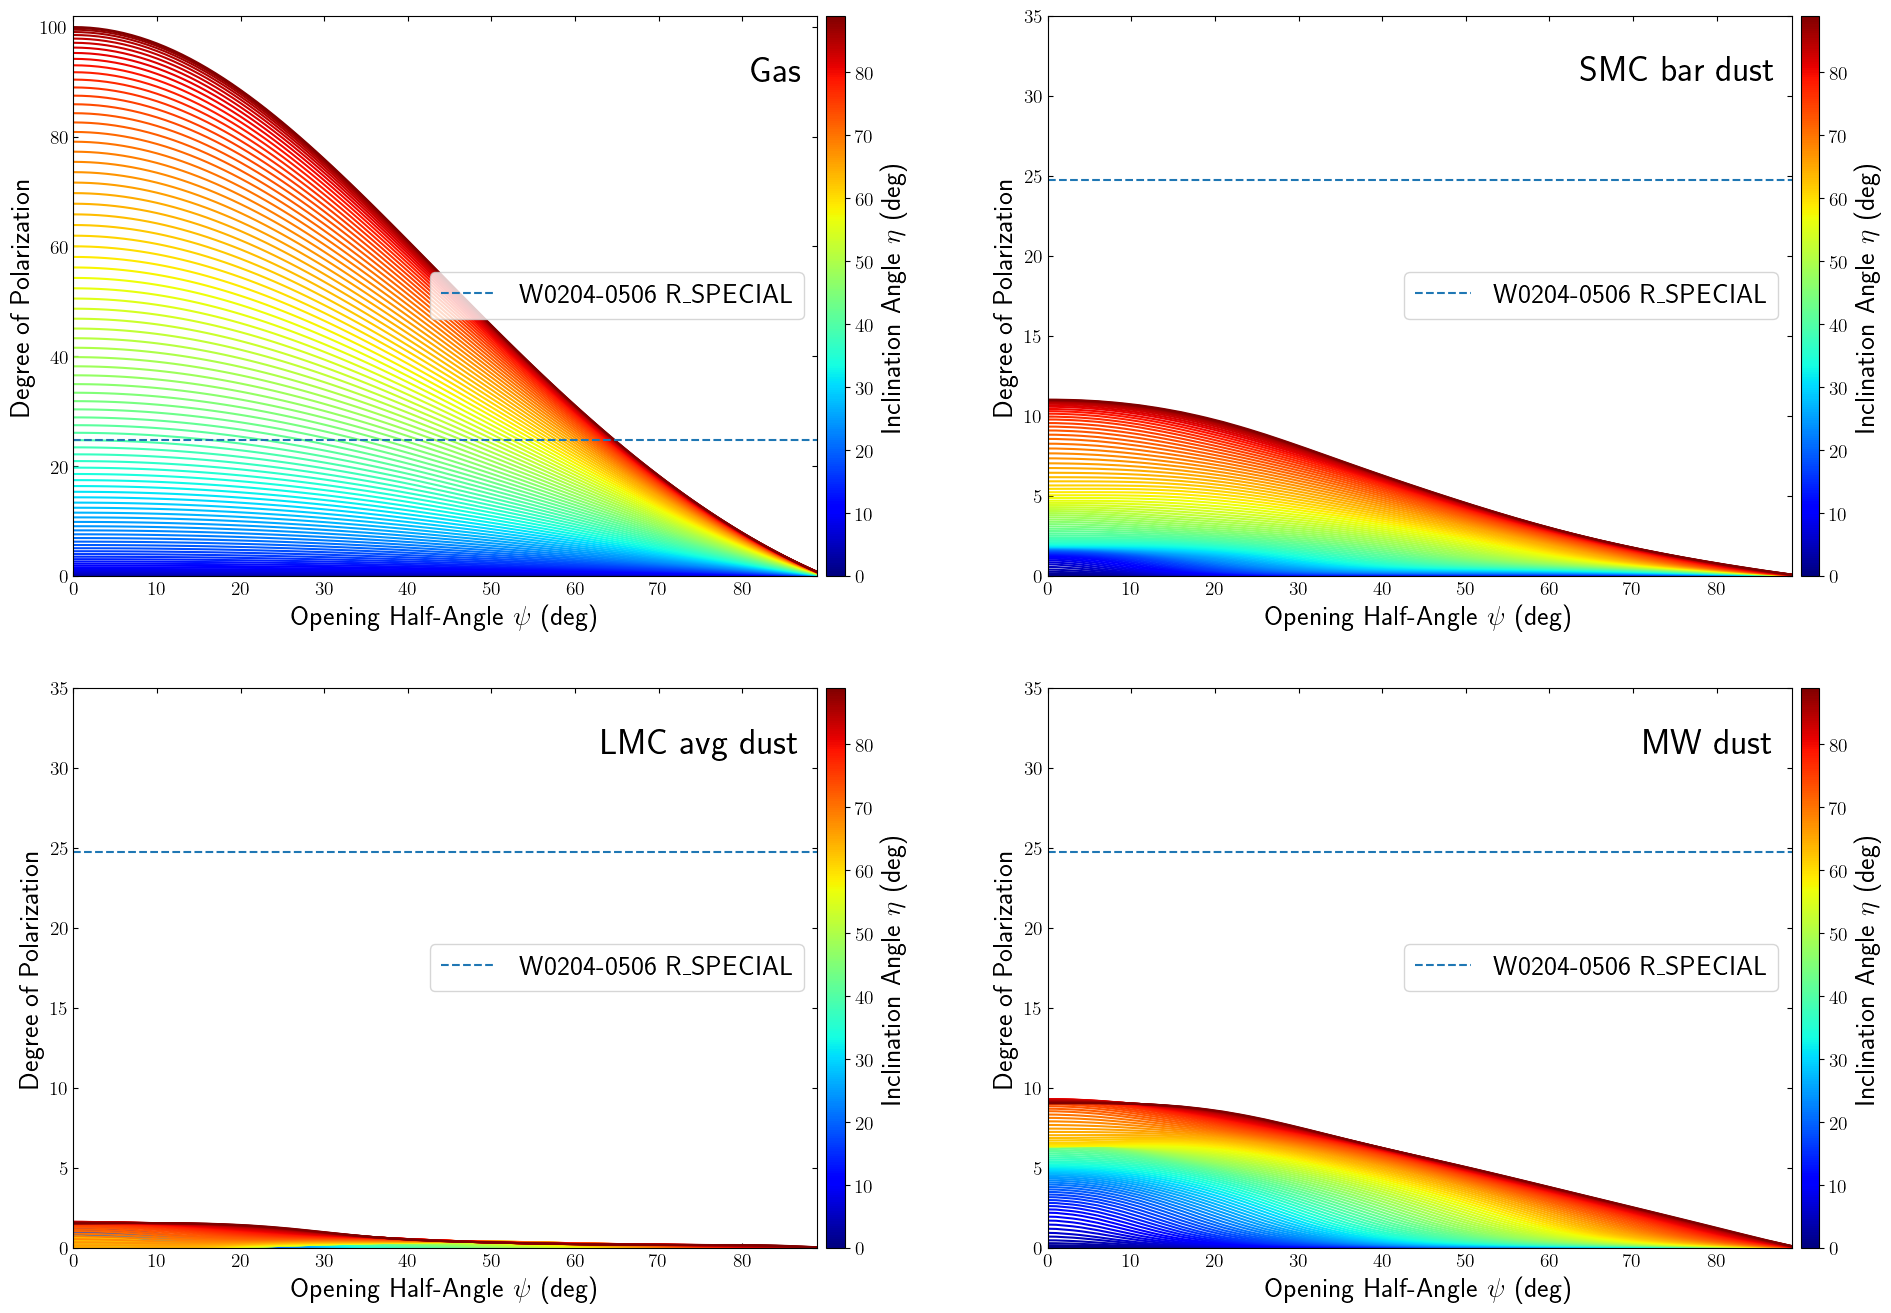

In [24]:
dust_models = ["gas", "SMC", "LMC", "MW"]
plot_labels = ["Gas", "SMC bar dust", "LMC avg dust", "MW dust"]
fw = True
bw = True
suffix = "FWBW"
for bname in bnames:

    fig, ax = plt.subplots(2,2,figsize=(24, 16))
    fig.subplots_adjust(wspace=0.1)
    plot_labels = ["Gas", "SMC bar dust", "LMC avg dust", "MW dust"]
    ymax = [1.02, 0.35, 0.35, 0.35]
    for k, dust_model in enumerate(dust_models):
        p_bb = get_p_bb(dust_model, theta_angles, psi_angles, specs, bnames, fw=fw, bw=bw)
        plot_pol(p_bb[bname]*100, theta_angles, psi_angles, plot_fname=None, plot_label=plot_labels[k], ymax=ymax[k]*100, fig=fig, ax=ax.flatten()[k])
        # #The detected polarization fraction. 
        # for key in pfrac.keys():
        puse = op.pfrac[wid][bname]
        ax.flatten()[k].plot([0, 90], [puse, puse], '--', label=wid+" "+bname)
        ax.flatten()[k].legend(loc=7, fontsize=20)
    plt.savefig("combined_pol.{}.{}.{}.png".format(wid,bname,suffix), dpi=100, bbox_inches='tight', transparent=False, facecolor='white')

In [ ]:
wid = "W0116-0505"
dust_models = ["gas", "SMC", "LMC", "MW"]
plot_labels = ["Gas", "SMC bar dust", "LMC avg dust", "MW dust"]
fw = True
bw = False
suffix = "FW"
for iband, band_name in enumerate(pol_data[wid]["bands"]):
    fig, ax = plt.subplots(2,2,figsize=(24, 16))
    fig.subplots_adjust(wspace=0.1)
    plot_labels = ["Gas", "SMC bar dust", "LMC avg dust", "MW dust"]
    ymax = [1.02, 0.35, 0.35, 0.35]
    for k, dust_model in enumerate(dust_models):
        p_bb = get_p_bb(dust_model, theta_angles, psi_angles, spec, [bands[iband]], fw=fw, bw=bw)
        plot_pol(p_bb[0], theta_angles, psi_angles, plot_fname=None, plot_label=plot_labels[k], ymax=ymax[k], fig=fig, ax=ax.flatten()[k])
        # #The detected polarization fraction. 
        # for key in pfrac.keys():
        puse = pol_data[wid]['pfrac'][iband]
        ax.flatten()[k].plot([0, 90], [puse, puse], '--', label=wid+" "+band_name)
        ax.flatten()[k].legend(loc=7, fontsize=20)
    plt.savefig("combined_pol.{}.{}.{}.png".format(wid,band_name,suffix), dpi=100, bbox_inches='tight', transparent=False, facecolor='white')

In [ ]:
wid = "W0116-0505"
dust_models = ["gas", "SMC", "LMC", "MW"]
plot_labels = ["Gas", "SMC bar dust", "LMC avg dust", "MW dust"]
fw = False
bw = True
suffix = "BW"
for iband, band_name in enumerate(pol_data[wid]["bands"]):
    fig, ax = plt.subplots(2,2,figsize=(24, 16))
    fig.subplots_adjust(wspace=0.1)
    plot_labels = ["Gas", "SMC bar dust", "LMC avg dust", "MW dust"]
    ymax = [1.02, 0.35, 0.35, 0.35]
    for k, dust_model in enumerate(dust_models):
        p_bb = get_p_bb(dust_model, theta_angles, psi_angles, spec, [bands[iband]], fw=fw, bw=bw)
        plot_pol(p_bb[0], theta_angles, psi_angles, plot_fname=None, plot_label=plot_labels[k], ymax=ymax[k], fig=fig, ax=ax.flatten()[k])
        # #The detected polarization fraction. 
        # for key in pfrac.keys():
        puse = pol_data[wid]['pfrac'][iband]
        ax.flatten()[k].plot([0, 90], [puse, puse], '--', label=wid+" "+band_name)
        ax.flatten()[k].legend(loc=7, fontsize=20)
    plt.savefig("combined_pol.{}.{}.{}.png".format(wid,band_name,suffix), dpi=100, bbox_inches='tight', transparent=False, facecolor='white')